<a href="https://colab.research.google.com/github/LongBaoNguyen/longbaonguyen.github.io/blob/master/courses/apcsp/image_processing/eigenfaces/intro_eigenfaces.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>


# Intro Eigenfaces Lab

## Math Seminar  


### Setup Yale Face Database and Upload Image Test

In [8]:
# %% [code] Setup
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

from skimage import data, color, transform, io
from PIL import Image
import requests
from io import BytesIO

np.random.seed(0)
plt.rcParams['figure.figsize'] = (6,4)

def show_grid(images, titles=None, ncols=6, cmap='gray', vmin=0, vmax=1, suptitle=None):
    n = len(images)
    nrows = int(ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            ax.imshow(images[i], cmap=cmap, vmin=vmin, vmax=vmax)
            if titles is not None and i < len(titles):
                ax.set_title(titles[i], fontsize=8)
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

# convert to grayscale
def to_gray(img):
    if img.ndim == 3:
        img = color.rgb2gray(img)
    img = img.astype(float)
    if img.max() > 1:
        img = img/255.0
    return img

In [9]:
# %% [code] Load the Yale Face Database from GitHub
base_url = "https://raw.githubusercontent.com/LongBaoNguyen/longbaonguyen.github.io/master/courses/apcsp/datasets/yale_faces/"

subjects = [f"subject{i:02d}" for i in range(1, 16)]
expressions = ["centerlight", "glasses", "happy", "leftlight", "noglasses",
               "normal", "rightlight", "sad", "sleepy", "surprised", "wink"]

H, W = 128, 96

faces = []
labels = []
print("Loading Yale Face Database...")
for sid, subj in enumerate(subjects):
    for expr in expressions:
        url = base_url + f"{subj}.{expr}"
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("L")
        img = np.asarray(img).astype(np.float64) / 255.0
        img = transform.resize(img, (H, W), anti_aliasing=True)
        faces.append(img)
        labels.append(sid)
    print(f"  Loaded {subj} ({sid+1}/15)")

faces = np.array(faces)
labels = np.array(labels)
n, H, W = faces.shape
X = faces.reshape(n, -1).T     # d × n
print(f"\nTotal: {faces.shape[0]} images, {len(subjects)} subjects, resized to {H}x{W}")



Loading Yale Face Database...
  Loaded subject01 (1/15)
  Loaded subject02 (2/15)
  Loaded subject03 (3/15)
  Loaded subject04 (4/15)
  Loaded subject05 (5/15)
  Loaded subject06 (6/15)
  Loaded subject07 (7/15)
  Loaded subject08 (8/15)
  Loaded subject09 (9/15)
  Loaded subject10 (10/15)
  Loaded subject11 (11/15)
  Loaded subject12 (12/15)
  Loaded subject13 (13/15)
  Loaded subject14 (14/15)
  Loaded subject15 (15/15)

Total: 165 images, 15 subjects, resized to 128x96


#### The second image of each person is the person wearing glasses. Write the numpy array that extract the image of the 7th person in the database from X. Then reshape it into the correct 2D shape 128 x 96 and plot it:
```python
plt.imshow(image, cmap=“gray”)
plt.show()
```

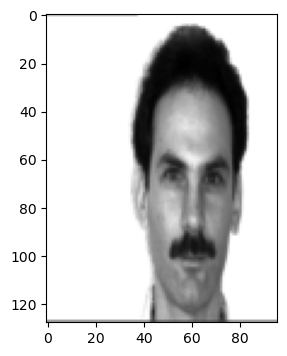

In [17]:
second_img = X[:, 11]
plt.imshow(second_img.reshape(128,96), cmap="gray")


#### If you want to plot multiple images each with dim 128 x 96, use show_grid function above. In this case, it's easier to use the faces array. What is faces.shape? Each image is a _____ in the array faces. Extract the first 5 images from the faces array by slicing and plot them by using show_grid.

In [9]:
# %% [code] Upload your face and reconstruct

# On Colab: pops up a file chooser dialog
try:
    from google.colab import files
    print("Click 'Choose Files' to upload your photo:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
except ImportError:
    filename = 'selfie.jpg'   # <-- local Jupyter: change to your image file

try:
    img = io.imread(filename)
    img = to_gray(img)
    
except FileNotFoundError:
    print(f"File '{filename}' not found. Upload your photo and re-run this cell.")

(12288, 165)

In [ ]:
plt.imshow(img, cmap="gray")


#### Plot your image

#### Convert to grayscale by calling to_gray above.

#### Crop it so that your image is 128 x 96. 

#### Plot it again to double check. 